<a href="https://colab.research.google.com/github/DivyaSadhana/Python_Cumulative-Projects/blob/main/Pharma_Commercials_Predictive_Analytics_with_AI_2026_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:

import random
import numpy as np
from datetime import datetime, timedelta

import pandas as pd
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
%matplotlib inline
sns.set(color_codes=True)

# Generate 100 sequential dates (to spread across 750 rows)
start_date = datetime(2023, 1, 1)
dates = [(start_date + timedelta(days=i)).strftime("%Y-%m-%d") for i in range(100)]

# Sample pharma products, brands, manufacturers
products = ["Paracetamol", "Ibuprofen", "Amoxicillin", "Cetirizine", "Metformin"]
brands = ["MediCare", "PharmaPlus", "HealthCorp", "BioLife", "CureWell"]
manufacturers = ["Sun Pharma", "Cipla", "Dr. Reddy's", "Pfizer", "Novartis"]

# Build messy dataset with 750 rows
data = {
    "Date": [random.choice(dates) for _ in range(750)],
    "Product": [random.choice(products) for _ in range(750)],
    "Brand": [random.choice(brands) for _ in range(750)],
    "Manufacturer": [random.choice(manufacturers) for _ in range(750)],
    "Quantity": [random.choice([None, random.randint(1, 200)]) for _ in range(750)],  # some nulls
    "Price": [random.choice([None, round(random.uniform(5, 500), 2)]) for _ in range(750)],  # some nulls
    "Region": [random.choice(["North", "South", "East", "West", None]) for _ in range(750)],  # nulls
    "SalesRep": [random.choice(["Amit", "Priya", "John", "Sara"]) for _ in range(750)]
}

df = pd.DataFrame(data)

# Introduce duplicates (first 20 rows repeated)
df = pd.concat([df, df.iloc[:20]], ignore_index=True)

# Preview first 10 rows and dataset shape
print(df.head(10))
print("Dataset shape:", df.shape)


         Date      Product       Brand Manufacturer  Quantity   Price Region  \
0  2023-01-23   Cetirizine    MediCare     Novartis       NaN     NaN  North   
1  2023-01-31    Metformin  PharmaPlus        Cipla       NaN     NaN   West   
2  2023-03-31    Ibuprofen  HealthCorp   Sun Pharma       NaN     NaN   None   
3  2023-03-29    Metformin  PharmaPlus  Dr. Reddy's       NaN  125.17  North   
4  2023-03-12    Ibuprofen  HealthCorp  Dr. Reddy's       NaN  459.99  North   
5  2023-02-08    Metformin    MediCare  Dr. Reddy's       NaN  123.37   East   
6  2023-03-29    Metformin    CureWell  Dr. Reddy's     153.0  204.93   West   
7  2023-02-28    Metformin    CureWell       Pfizer      73.0  265.28  North   
8  2023-02-23  Paracetamol  PharmaPlus   Sun Pharma       NaN  443.17   West   
9  2023-01-23  Paracetamol    MediCare     Novartis       NaN  268.10  South   

  SalesRep  
0     Amit  
1     Amit  
2     John  
3    Priya  
4     Sara  
5    Priya  
6     Amit  
7    Priya  
8 

In [49]:
df = pd.DataFrame(data)

In [12]:
df1 = df.head(20)
df1

,Date,Product,Brand,Manufacturer,Quantity,Price,Region,SalesRep
0,2023-03-23,Ibuprofen,BioLife,Novartis,NaN,365.52,West,Sara
1,2023-02-08,Cetirizine,HealthCorp,Dr. Reddy's,NaN,NaN,East,John
2,2023-02-10,Amoxicillin,CureWell,Sun Pharma,NaN,NaN,East,Sara
3,2023-04-01,Metformin,MediCare,Dr. Reddy's,NaN,NaN,None,Amit
4,2023-01-06,Cetirizine,CureWell,Pfizer,37.0,NaN,South,Priya
5,2023-02-01,Paracetamol,HealthCorp,Pfizer,NaN,35.59,East,Amit
6,2023-01-15,Amoxicillin,BioLife,Sun Pharma,NaN,201.58,East,John
7,2023-01-11,Metformin,CureWell,Sun Pharma,NaN,NaN,None,Priya
8,2023-02-14,Amoxicillin,CureWell,Sun Pharma,NaN,485.58,East,Priya
9,2023-01-11,Metformin,MediCare,Sun Pharma,107.0,364.15,West,Sara


In [34]:
# Fetch total number of rows and Columns
df1 = df.shape
df1

(750, 8)

In [50]:
# Check null values existence in each column.
print(df.isnull().sum())


Date              0
Product           0
Brand             0
Manufacturer      0
Quantity        387
Price           364
Region          135
SalesRep          0
dtype: int64


#                                  **Data** **Cleaning**

In [51]:
# 1. Drop Duplicate data if exists.

DataFrame = df.drop_duplicates()
DataFrame.shape

(750, 8)

In [52]:
# 2. Drop Null Values

DataFrame = df.dropna()
DataFrame

,Date,Product,Brand,Manufacturer,Quantity,Price,Region,SalesRep
3,2023-01-18,Cetirizine,PharmaPlus,Sun Pharma,114.0,251.89,West,Priya
9,2023-03-16,Ibuprofen,CureWell,Dr. Reddy's,84.0,178.38,South,John
21,2023-02-02,Metformin,PharmaPlus,Cipla,96.0,47.13,West,John
24,2023-01-28,Paracetamol,HealthCorp,Dr. Reddy's,99.0,211.51,North,John
31,2023-03-30,Amoxicillin,BioLife,Dr. Reddy's,16.0,38.56,North,Priya
...,...,...,...,...,...,...,...,...
725,2023-01-31,Metformin,HealthCorp,Novartis,134.0,28.60,South,Sara
726,2023-02-10,Paracetamol,HealthCorp,Cipla,153.0,459.60,North,Sara
733,2023-01-18,Metformin,CureWell,Novartis,67.0,180.83,South,Amit
734,2023-03-01,Paracetamol,PharmaPlus,Cipla,56.0,22.01,West,John


In [53]:
# 3. Identify total rows count after dropping null values.

DataFrame.shape


(151, 8)

In [54]:
# 4. Identify the Data Types of all columns
DataFrame.dtypes

,0
Date,object
Product,object
Brand,object
Manufacturer,object
Quantity,float64
Price,float64
Region,object
SalesRep,object


In [55]:
# 5. Stastical Inferences.

DataFrame.describe()

,Quantity,Price
count,151.000000,151.000000
mean,95.350993,256.109934
std,60.213863,143.489651
min,1.000000,12.430000
25%,40.000000,125.420000
50%,93.000000,261.690000
75%,144.000000,377.395000
max,200.000000,496.400000


In [56]:
#6. Add new column 'Revenue'.
DataFrame['Revenue'] = DataFrame['Quantity'] * DataFrame['Price']
DataFrame

/tmp/ipykernel_4853/2387235029.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DataFrame['Revenue'] = DataFrame['Quantity'] * DataFrame['Price']


,Date,Product,Brand,Manufacturer,Quantity,Price,Region,SalesRep,Revenue
3,2023-01-18,Cetirizine,PharmaPlus,Sun Pharma,114.0,251.89,West,Priya,28715.46
9,2023-03-16,Ibuprofen,CureWell,Dr. Reddy's,84.0,178.38,South,John,14983.92
21,2023-02-02,Metformin,PharmaPlus,Cipla,96.0,47.13,West,John,4524.48
24,2023-01-28,Paracetamol,HealthCorp,Dr. Reddy's,99.0,211.51,North,John,20939.49
31,2023-03-30,Amoxicillin,BioLife,Dr. Reddy's,16.0,38.56,North,Priya,616.96
...,...,...,...,...,...,...,...,...,...
725,2023-01-31,Metformin,HealthCorp,Novartis,134.0,28.60,South,Sara,3832.40
726,2023-02-10,Paracetamol,HealthCorp,Cipla,153.0,459.60,North,Sara,70318.80
733,2023-01-18,Metformin,CureWell,Novartis,67.0,180.83,South,Amit,12115.61
734,2023-03-01,Paracetamol,PharmaPlus,Cipla,56.0,22.01,West,John,1232.56


In [73]:
DataFrame = DataFrame.rename(columns={"Brand": "BrandName", "SalesRep": "SalesRepresentative"})
DataFrame.head()

,Date,Product,BrandName,Manufacturer,Quantity,Price,Region,SalesRepresentative,Revenue
3,2023-01-18,Cetirizine,PharmaPlus,Sun Pharma,114.0,251.89,West,Priya,28715.46
9,2023-03-16,Ibuprofen,CureWell,Dr. Reddy's,84.0,178.38,South,John,14983.92
21,2023-02-02,Metformin,PharmaPlus,Cipla,96.0,47.13,West,John,4524.48
24,2023-01-28,Paracetamol,HealthCorp,Dr. Reddy's,99.0,211.51,North,John,20939.49
31,2023-03-30,Amoxicillin,BioLife,Dr. Reddy's,16.0,38.56,North,Priya,616.96


<Axes: xlabel='Price'>

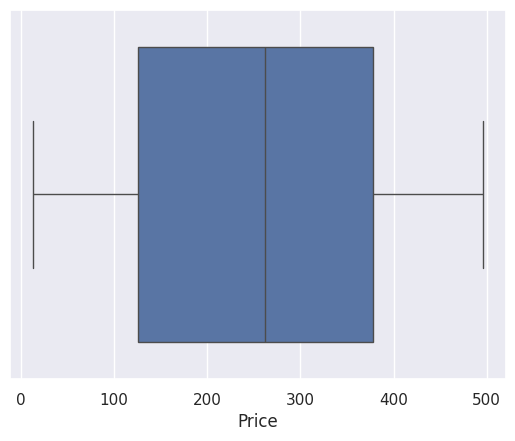

In [64]:
sns.boxplot(x=DataFrame['Price'])


<Axes: xlabel='Revenue'>

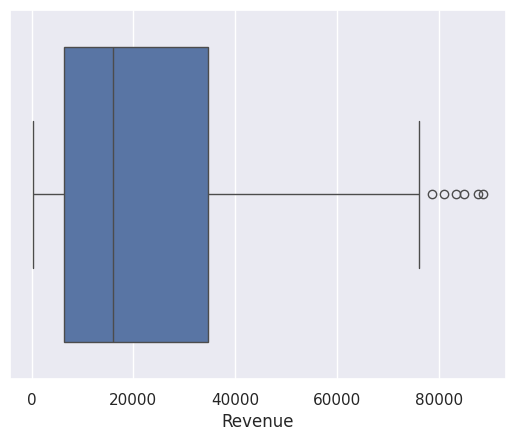

In [65]:
sns.boxplot(x=DataFrame['Revenue'])

In [68]:
# Calculate Q1 and Q3 using quantile
Q1 = DataFrame["Revenue"].quantile(0.25)
Q3 = DataFrame["Revenue"].quantile(0.75)

# Interquartile Range
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)


Q1: 6449.86
Q3: 34657.14
IQR: 28207.28


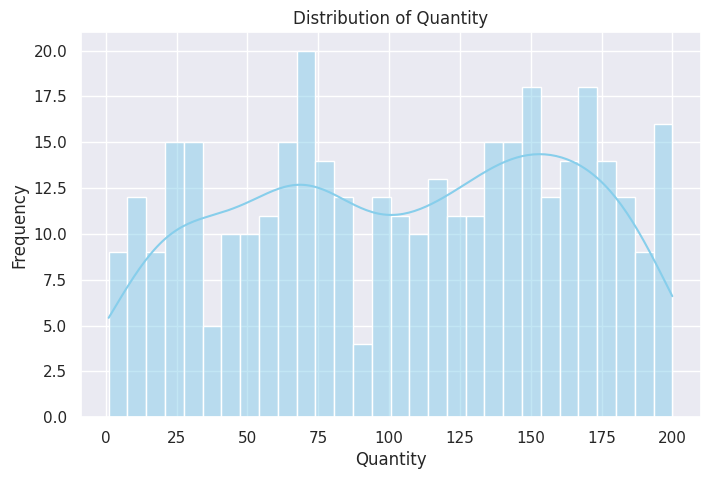

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of Quantity
plt.figure(figsize=(8,5))
sns.histplot(df["Quantity"], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()


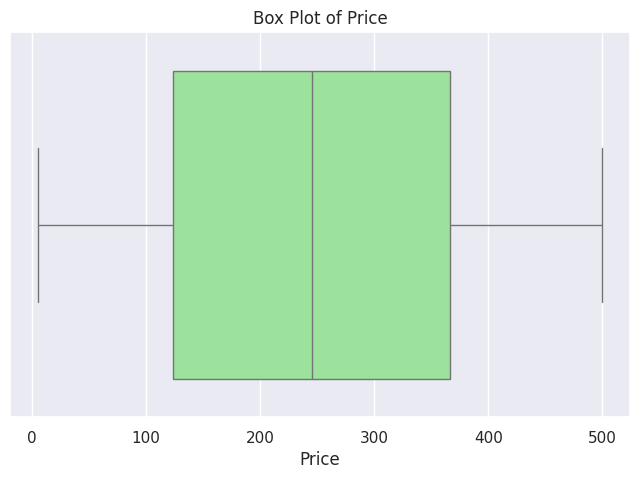

In [70]:
# Box plot of Price
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Price"], color="lightgreen")
plt.title("Box Plot of Price")
plt.xlabel("Price")
plt.show()


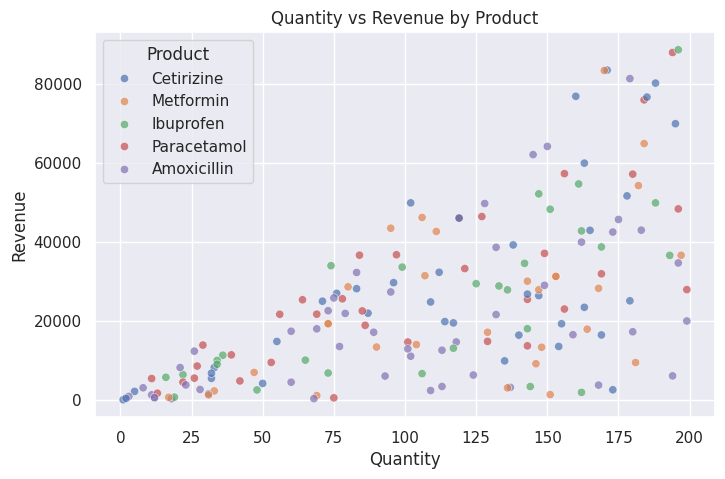

In [80]:
# Ensure Revenue exists before plotting
df["Revenue"] = df["Quantity"] * df["Price"]

# Scatter Plot
plt.figure(figsize=(8,5))
sns.scatterplot(x="Quantity", y="Revenue", data=df, hue="Product", alpha=0.7)
plt.title("Quantity vs Revenue by Product")
plt.show()




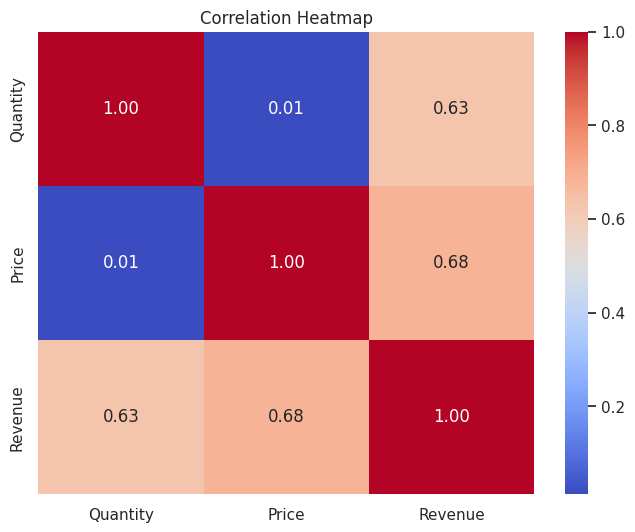

In [81]:
#Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df[["Quantity","Price","Revenue"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

